# 05 — Vietnam Satellite Coverage & SIKD Performance Analysis
# (Paper 1 Style: Fig 5, 8-9, 10)

Phân tích coverage vệ tinh Starlink qua Hà Nội và các thành phố Việt Nam.
Tái tạo theo style Paper 1 (Vu et al., IEEE Access 2022):
- **Fig 5**: Elevation angle vs elapsed time — nhiều vệ tinh, chia theo orbital group
- **Fig 8-9**: Psift và QBER vs (elapsed time × ζ_scale) — 2D contourf
- **Fig 10**: Coverage area + communication time duration map

## Nội dung
1. Tạo constellation Starlink synthetic (176 sats, 8 planes × 22 sats)
2. Tìm cửa sổ thời gian tốt nhất — nhiều vệ tinh visible cùng lúc
3. Fig 5 style: Elevation vs elapsed time, grouped by orbital plane
4. Chọn vệ tinh tốt nhất — Fig 8-9 style: Psift/QBER contourf
5. Fig 10 style: Coverage area + comm time map
6. Multi-city comparison: Hà Nội, Đà Nẵng, TP.HCM

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timezone, timedelta

from modules.orbital_mechanics import (
    parse_tle_block, make_skyfield_satellite, fetch_tle_celestrak,
    compute_elevation_timeseries, find_pass_windows,
    make_time_array, GROUND_STATIONS, _TS,
)
from modules.channel_model import compute_channel, compute_hl
from modules.sikd_performance import compute_sikd_performance, compute_Psift_QBER, compute_noise, compute_thresholds
from modules.weather_model import get_city_params
from skyfield.api import wgs84

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5,
})

# Paper 2 nominal parameters
PARAMS = dict(PT=1.0, mK=0.05, mD=0.5, Iso_dB=15.0, zeta_scale=2.0, Rb=1e9)
H_S_KM  = 500.0
MIN_ELEV = 30.0   # Paper 1: minimum tracking elevation = 30°

# Reference time: 2026-03-12 12:00 UTC
T_REF = datetime(2026, 3, 12, 12, 0, 0, tzinfo=timezone.utc)

# --- Helper: Draw Hoang Sa / Truong Sa on any axes ---
# Island coordinates from Wikipedia/CIA World Factbook (public domain)
_HOANG_SA_COORDS = [  # (lon, lat) of major features
    (112.3333, 16.8333),  # Woody Island
    (112.7333, 16.6667),  # Lincoln Island
    (111.2000, 15.7833),  # Triton Island
    (111.7667, 16.4667),  # Drummond Island
    (111.6000, 16.5333),  # Pattle Island
    (111.6667, 16.2500),  # Discovery Reef
    (112.5333, 16.0333),  # Bombay Reef
    (111.5167, 17.0833),  # North Reef
    (112.2667, 16.9667),  # Tree Island
]
_TRUONG_SA_COORDS = [  # (lon, lat) of Vietnam-claimed features
    (111.9167, 8.6333),   # Spratly Island
    (114.3333, 11.4333),  # Southwest Cay
    (114.3667, 10.1833),  # Namyit Island
    (114.3333, 9.8833),   # Sin Cowe Island
    (114.4833, 10.3833),  # Sand Cay
    (112.9167, 7.8833),   # Amboyna Cay
    (113.3167, 8.1500),   # Barque Canada Reef
    (113.6833, 8.9500),   # Pearson Reef
    (114.6500, 8.8500),   # Tennent Reef
    (114.2000, 8.7167),   # Cornwallis South Reef
]

def draw_vietnam_islands(ax, use_cartopy=True):
    """Draw Hoang Sa and Truong Sa using actual island positions + convex hull."""
    from scipy.spatial import ConvexHull
    kwargs = {}
    if use_cartopy:
        kwargs = {'transform': ccrs.PlateCarree()}
    for coords, label, offset in [
        (_HOANG_SA_COORDS, 'Quần đảo\nHoàng Sa', (0.3, 0.3)),
        (_TRUONG_SA_COORDS, 'Quần đảo\nTrường Sa', (0.3, 0.3)),
    ]:
        pts = np.array(coords)
        lons, lats = pts[:, 0], pts[:, 1]
        ax.scatter(lons, lats, s=8, color='#c00000', marker='^', zorder=6,
                   linewidths=0.3, edgecolors='darkred', **kwargs)
        hull = ConvexHull(pts)
        hull_pts = pts[hull.vertices]
        hull_pts = np.vstack([hull_pts, hull_pts[0]])
        ax.plot(hull_pts[:, 0], hull_pts[:, 1], color='#c00000',
                linewidth=1.0, linestyle='--', zorder=5, **kwargs)
        cx, cy = lons.mean(), lats.mean()
        ax.text(cx + offset[0], cy + offset[1], label,
                fontsize=5.5, color='#c00000', ha='center', va='center',
                fontweight='bold', zorder=7, **kwargs)

print('Modules loaded OK')
print(f'Reference time: {T_REF}')
print(f'Min tracking elevation: {MIN_ELEV}°  (Paper 1 standard)')

Modules loaded OK
Reference time: 2026-03-12 12:00:00+00:00
Min tracking elevation: 30.0°  (Paper 1 standard)


## 1. Starlink Constellation — 176 Synthetic Satellites (8 planes × 22 sats)

Tạo constellation Starlink synthetic với mật độ thực tế:
- 8 orbital planes, RAAN cách nhau 45°
- 22 satellites/plane, mean anomaly cách nhau 16.4°
- Inclination 53°, altitude 550 km (Paper 1 Table 3)
- Chia thành 4 groups (I–IV) theo cặp planes, giống Paper 1 Fig 5

In [2]:
# Try CelesTrak first; fall back to synthetic constellation
print('Attempting CelesTrak download...')
use_real_tle = False
try:
    tle_dicts_real = fetch_tle_celestrak('starlink', timeout=15)
    if len(tle_dicts_real) > 100:
        tle_dicts = tle_dicts_real
        use_real_tle = True
        print(f'Downloaded {len(tle_dicts)} real Starlink TLEs')
    else:
        raise ValueError('Too few satellites')
except Exception as e:
    print(f'CelesTrak unavailable ({e}). Using synthetic constellation.')

if not use_real_tle:
    # Generate 8 planes × 22 sats = 176 satellites
    # Matching Starlink shell 1: 53° inclination, 550 km, 15.05 rev/day
    INC, N_REV, EPOCH = 53.0, 15.05, '26071.50000000'
    N_PLANES, N_PER_PLANE = 8, 22
    PLANE_LABELS = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII']
    # Groups: Paper 1 uses 4 groups of 2 planes each
    # Group I=planes 0,1; II=planes 2,3; III=planes 4,5; IV=planes 6,7
    GROUP_MAP = {0:'I', 1:'I', 2:'II', 3:'II', 4:'III', 5:'III', 6:'IV', 7:'IV'}

    lines = []
    sat_num = 44235
    for p_idx in range(N_PLANES):
        raan = p_idx * (360.0 / N_PLANES)
        for k in range(N_PER_PLANE):
            M0 = k * (360.0 / N_PER_PLANE)
            grp = GROUP_MAP[p_idx]
            name = f'SL-{grp}-{PLANE_LABELS[p_idx]}{k+1:02d}'
            l1 = (f'1 {sat_num:05d}U 19029X   {EPOCH}  .00001000  '
                  f'00000-0  10000-3 0  999{k%10}')
            l2 = (f'2 {sat_num:05d} {INC:8.4f} {raan:8.4f} 0001000 '
                  f' 90.0000 {M0:8.4f} {N_REV:.8f} 0000{k%10}')
            lines.append(name); lines.append(l1); lines.append(l2)
            sat_num += 1

    tle_dicts = parse_tle_block('\n'.join(lines))
    print(f'Generated {len(tle_dicts)} synthetic satellites '
          f'({N_PLANES} planes × {N_PER_PLANE} sats)')

satellites = [make_skyfield_satellite(d) for d in tle_dicts]
# Extract group label from name (works for both real and synthetic)
def get_group(name):
    """Extract orbital group from satellite name."""
    if name.startswith('SL-'):
        parts = name.split('-')
        return parts[1] if len(parts) >= 2 else 'X'
    return 'X'  # real TLE: group by RAAN clustering later

print(f'Loaded {len(satellites)} satellites')
print(f'Example names: {[s.name for s in satellites[:4]]}')

Attempting CelesTrak download...


CelesTrak unavailable (CelesTrak returned HTTP 403 for group 'starlink'). Using synthetic constellation.
Generated 176 synthetic satellites (8 planes × 22 sats)
Loaded 176 satellites
Example names: ['SL-I-I01', 'SL-I-I02', 'SL-I-I03', 'SL-I-I04']


## 2. Tìm cửa sổ thời gian tốt nhất — Hà Nội

Scan 24h để tìm window ~3000s khi có nhiều vệ tinh visible (elev ≥ 30°) nhất.
Giống Paper 1: họ chọn "second cycle" từ 16:09:00 UTC+9, 2021/12/23.

In [3]:
gs_hanoi = GROUND_STATIONS['hanoi']

# Scan 24h with 1-min steps to find best window
print('Scanning 24h for best visibility window over Hanoi...')
n_scan = 24 * 60
t_scan_list = [T_REF + timedelta(minutes=i) for i in range(n_scan)]
t_scan = _TS.from_datetimes(t_scan_list)

obs_hanoi = wgs84.latlon(gs_hanoi['lat'], gs_hanoi['lon'], elevation_m=gs_hanoi['alt_m'])
visible_count = np.zeros(n_scan)
sat_elevs_24h = {}

for sat in satellites:
    diff = sat - obs_hanoi
    topo = diff.at(t_scan)
    alt, _, _ = topo.altaz()
    elevs = np.array(alt.degrees)
    sat_elevs_24h[sat.name] = elevs
    visible_count += (elevs >= MIN_ELEV).astype(float)

# Find best 50-min window (3000s)
WIN_MIN = 50
best_start, best_score = 0, 0
for i in range(n_scan - WIN_MIN):
    score = visible_count[i:i+WIN_MIN].sum()
    if score > best_score:
        best_score = score
        best_start = i

WIN_START_MIN = best_start
WIN_END_MIN   = best_start + WIN_MIN
T_WIN_START   = T_REF + timedelta(minutes=WIN_START_MIN)

print(f'Best window: T+{WIN_START_MIN}min to T+{WIN_END_MIN}min '
      f'({WIN_MIN} min = {WIN_MIN*60}s)')
print(f'Window start: {T_WIN_START}')
print(f'Max simultaneous visible: {visible_count[WIN_START_MIN:WIN_END_MIN].max():.0f}')

# Find all satellites visible in this window
visible_in_window = []
for sat in satellites:
    elevs_win = sat_elevs_24h[sat.name][WIN_START_MIN:WIN_END_MIN]
    max_el = elevs_win.max()
    if max_el >= MIN_ELEV:
        grp = get_group(sat.name)
        visible_in_window.append({
            'sat': sat, 'name': sat.name, 'group': grp,
            'elevs': elevs_win, 'max_el': max_el,
        })

visible_in_window.sort(key=lambda x: x['max_el'], reverse=True)
print(f'\nSatellites visible in window ({len(visible_in_window)} total):')
for v in visible_in_window:
    print(f'  {v["name"]:20s}  Group {v["group"]}  max_el={v["max_el"]:5.1f}°')

Scanning 24h for best visibility window over Hanoi...
Best window: T+395min to T+445min (50 min = 3000s)
Window start: 2026-03-12 18:35:00+00:00
Max simultaneous visible: 2

Satellites visible in window (20 total):
  SL-III-V16            Group III  max_el= 86.0°
  SL-I-II13             Group I  max_el= 82.1°
  SL-I-II14             Group I  max_el= 73.7°
  SL-III-V14            Group III  max_el= 71.3°
  SL-III-V15            Group III  max_el= 70.6°
  SL-I-II15             Group I  max_el= 69.3°
  SL-I-II16             Group I  max_el= 60.7°
  SL-III-V13            Group III  max_el= 59.8°
  SL-III-V12            Group III  max_el= 54.9°
  SL-I-II17             Group I  max_el= 53.7°
  SL-I-II18             Group I  max_el= 47.8°
  SL-III-V11            Group III  max_el= 47.6°
  SL-III-V10            Group III  max_el= 42.6°
  SL-I-II19             Group I  max_el= 41.8°
  SL-III-V09            Group III  max_el= 37.9°
  SL-I-II20             Group I  max_el= 37.8°
  SL-III-V08     

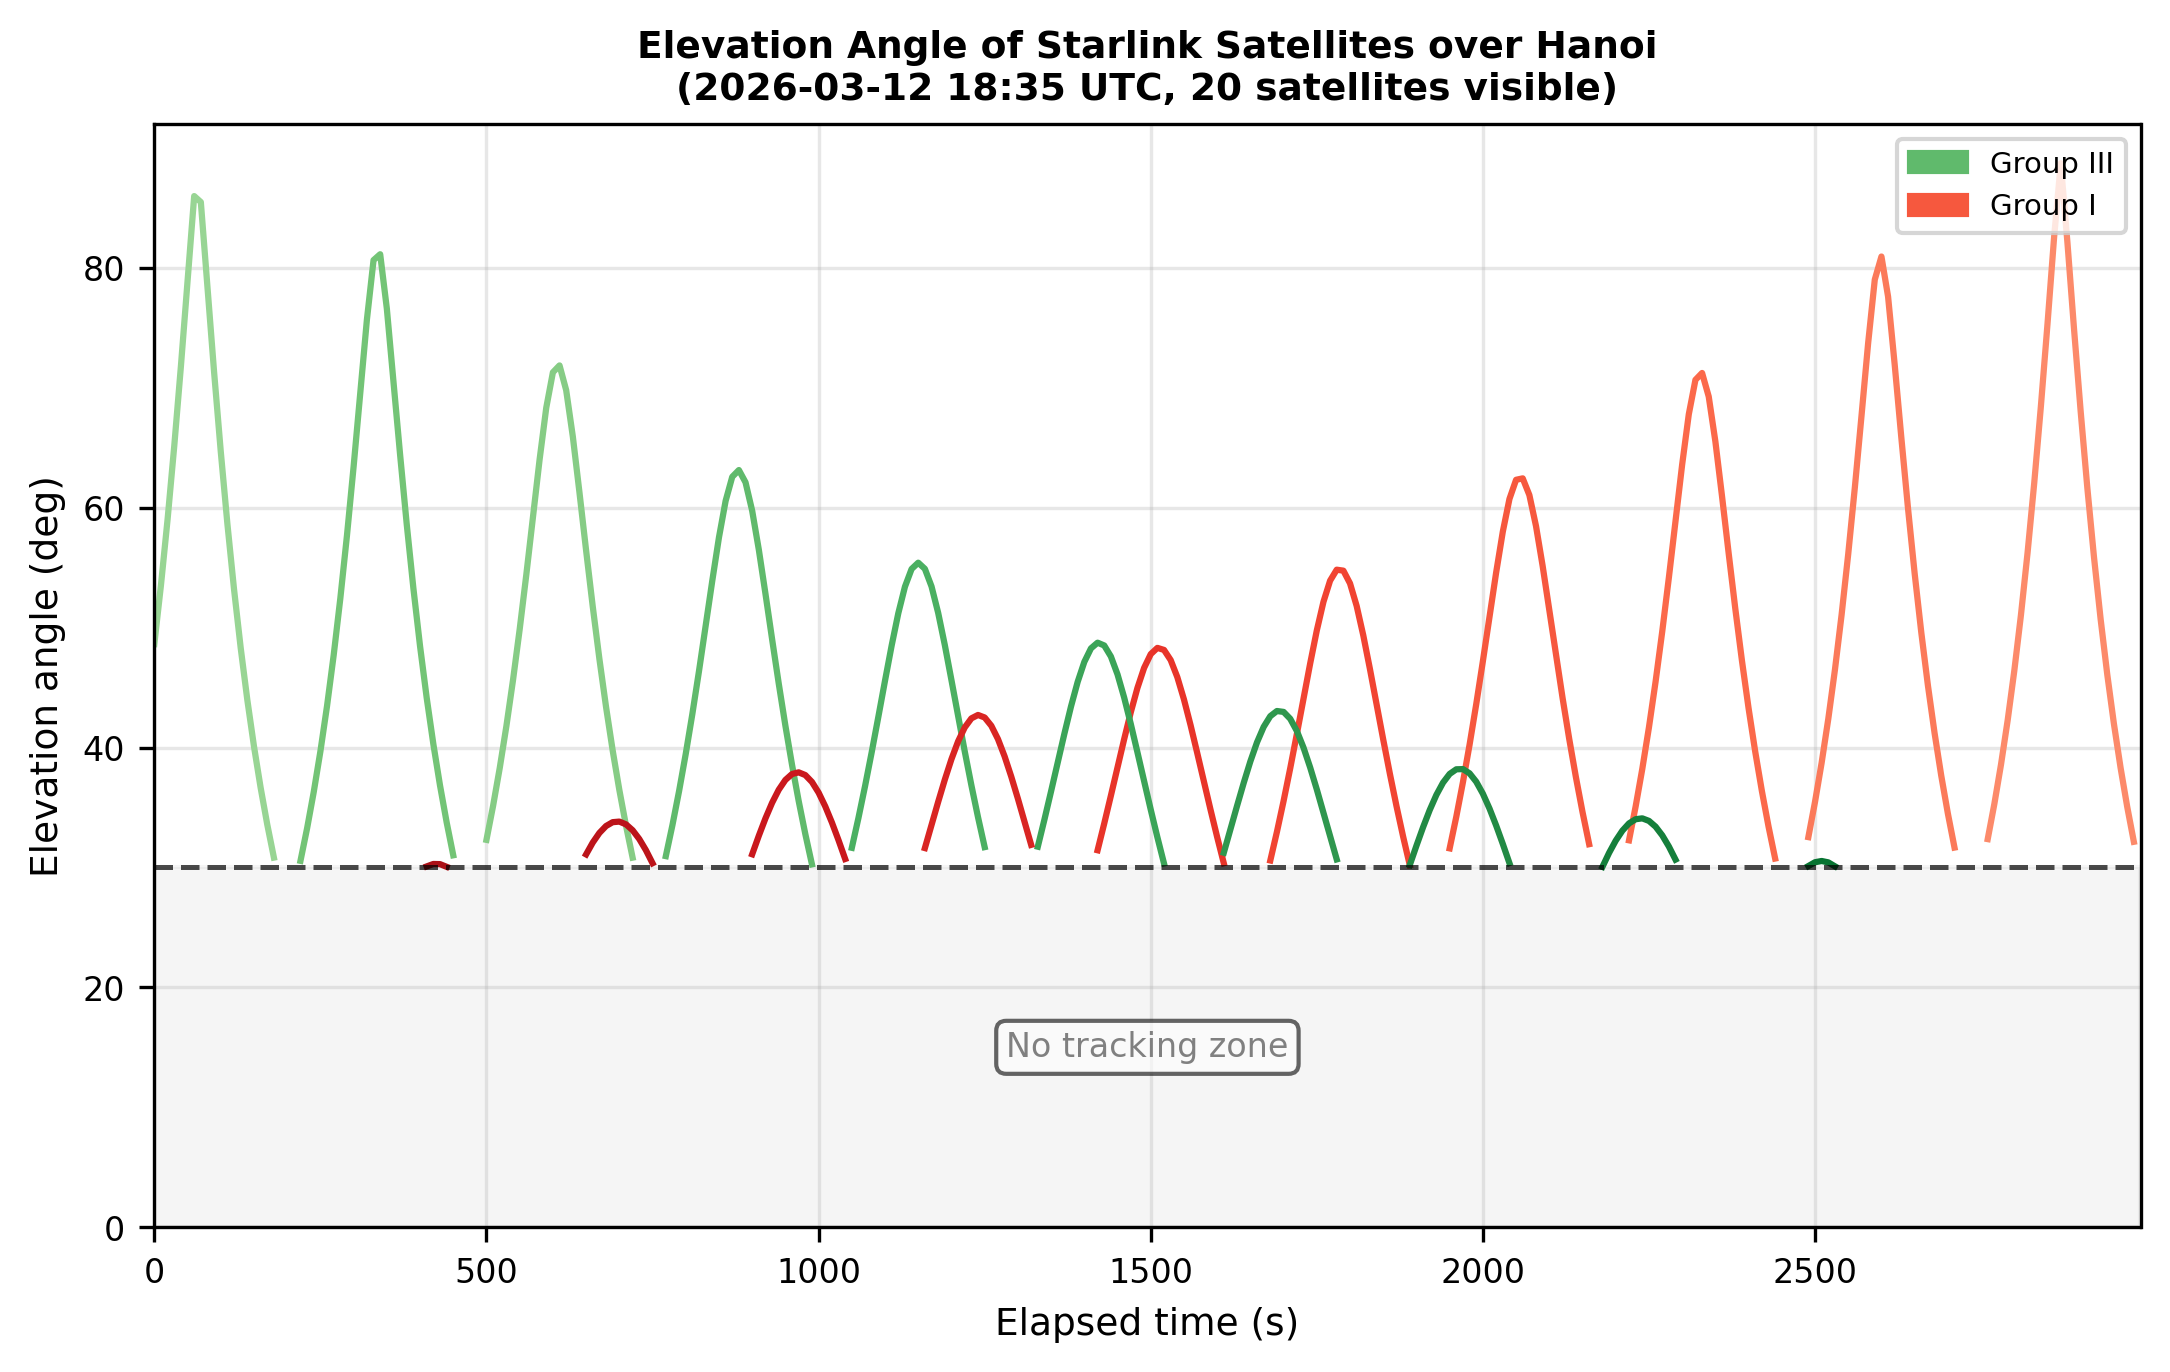

Satellites visible: 20
Groups: {'III', 'I'}


In [4]:
## Fig 5 Style: Elevation Angle vs Elapsed Time — Grouped by Orbital Plane

# Build fine-resolution time array for the window (10s steps)
n_fine = WIN_MIN * 6  # 10s steps
t_fine_list = [T_WIN_START + timedelta(seconds=i*10) for i in range(n_fine)]
t_fine = _TS.from_datetimes(t_fine_list)
elapsed_s = np.arange(n_fine) * 10.0  # seconds

# Compute fine-resolution elevations for visible satellites
for v in visible_in_window:
    diff = v['sat'] - obs_hanoi
    topo = diff.at(t_fine)
    alt, _, _ = topo.altaz()
    v['elevs_fine'] = np.array(alt.degrees)

# Group colors — Paper 1 style
GROUP_COLORS = {
    'I':   {'colors': plt.cm.Reds(np.linspace(0.4, 0.9, 11)),   'label': 'Group I'},
    'II':  {'colors': plt.cm.Blues(np.linspace(0.4, 0.9, 11)),  'label': 'Group II'},
    'III': {'colors': plt.cm.Greens(np.linspace(0.4, 0.9, 11)), 'label': 'Group III'},
    'IV':  {'colors': plt.cm.Oranges(np.linspace(0.4, 0.9, 11)),'label': 'Group IV'},
}
GROUP_COLORS['X'] = {'colors': plt.cm.tab20(np.linspace(0, 1, 20)), 'label': 'Starlink'}

group_counters = {g: 0 for g in GROUP_COLORS}

fig, ax = plt.subplots(figsize=(7.16, 4.5))

legend_handles = {}
for v in visible_in_window:
    grp = v['group']
    if grp not in group_counters:
        grp = 'X'
    ci = group_counters[grp] % len(GROUP_COLORS[grp]['colors'])
    color = GROUP_COLORS[grp]['colors'][ci]
    group_counters[grp] += 1

    elev_plot = np.where(v['elevs_fine'] >= MIN_ELEV, v['elevs_fine'], np.nan)
    line, = ax.plot(elapsed_s, elev_plot, color=color, linewidth=1.5)

    if grp not in legend_handles:
        legend_handles[grp] = mpatches.Patch(
            color=GROUP_COLORS[grp]['colors'][3],
            label=f'Group {grp}' if grp != 'X' else 'Starlink'
        )

ax.axhline(MIN_ELEV, color='k', linestyle='--', linewidth=1.2, alpha=0.7)
ax.fill_between(elapsed_s, 0, MIN_ELEV, alpha=0.08, color='gray')
ax.text(elapsed_s[-1]*0.5, MIN_ELEV/2, 'No tracking zone',
        ha='center', va='center', fontsize=8, color='gray',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))

ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel('Elevation angle (deg)')
ax.set_title(f'Elevation Angle of Starlink Satellites over Hanoi\n'
             f'({T_WIN_START.strftime("%Y-%m-%d %H:%M UTC")}, '
             f'{len(visible_in_window)} satellites visible)',
             fontsize=9, fontweight='bold')
ax.set_xlim(0, elapsed_s[-1])
ax.set_ylim(0, 92)
ax.legend(handles=list(legend_handles.values()), loc='upper right', fontsize=7)
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig16_elevation_vs_time_hanoi.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Satellites visible: {len(visible_in_window)}')
print(f'Groups: {set(v["group"] for v in visible_in_window)}')

## 3. Best Satellite — Fig 8-9 Style: Psift & QBER Contourf

Chọn vệ tinh có max elevation cao nhất (representative, như Paper 1 chọn Starlink-1293).
Plot Psift và QBER như hàm của (elapsed time × ζ_scale) — 2D contourf.
Operational region: Psift ≥ 10⁻³ AND QBER ≤ 10⁻²

In [5]:
# Select best satellite (highest max elevation)
best = visible_in_window[0]
best_sat = best['sat']
print(f'Best satellite: {best["name"]}')
print(f'Max elevation: {best["max_el"]:.1f}°, Group: {best["group"]}')

# Find pass window for best satellite (fine resolution)
pass_mask = best['elevs_fine'] >= MIN_ELEV
pass_indices = np.where(pass_mask)[0]
if len(pass_indices) == 0:
    raise ValueError('No pass found for best satellite')

pass_start_idx = pass_indices[0]
pass_end_idx   = pass_indices[-1]
pass_elapsed   = elapsed_s[pass_start_idx:pass_end_idx+1]
pass_elevs     = best['elevs_fine'][pass_start_idx:pass_end_idx+1]
pass_dur_s     = pass_elapsed[-1] - pass_elapsed[0]

print(f'Pass: t={pass_elapsed[0]:.0f}s to t={pass_elapsed[-1]:.0f}s '
      f'(duration={pass_dur_s:.0f}s = {pass_dur_s/60:.1f} min)')
print(f'Peak elevation: {pass_elevs.max():.1f}° at t={pass_elapsed[np.argmax(pass_elevs)]:.0f}s')

# ζ_scale range to test (Paper 1: 0 to 4)
zeta_c_range = np.linspace(0.5, 4.0, 50)

# For Fig 8-9 style: use Iso=20dB to get visible QBER variation
# (Iso=15dB gives QBER~10% always; Iso=20dB gives QBER range 1e-3 to 5e-2 → operational region visible)
ISO_FIG89 = 20.0
PARAMS_FIG89 = dict(PT=1.0, mK=0.05, mD=0.5, Iso_dB=ISO_FIG89, zeta_scale=2.0, Rb=1e9)

wx_dry = get_city_params('hanoi', 1)
wx_wet = get_city_params('hanoi', 7)

n_t = len(pass_elapsed)
n_z = len(zeta_c_range)
Psift_grid = np.zeros((n_z, n_t))
QBER_grid  = np.zeros((n_z, n_t))

print(f'Computing Psift/QBER grid ({n_z}×{n_t}), Iso={ISO_FIG89}dB...')
for t_idx, (t_s, elev) in enumerate(zip(pass_elapsed, pass_elevs)):
    if elev < MIN_ELEV:
        continue
    zeta = 90.0 - elev
    ch = compute_channel(H_S_KM, zeta)
    hl = compute_hl(zeta_deg=zeta, V_km=wx_dry['V_km'], R_mm_h=wx_dry['R_mm_h'])

    for z_idx, zc in enumerate(zeta_c_range):
        noise = compute_noise(ch['hg'], hl, PARAMS_FIG89['PT'], PARAMS_FIG89['mK'],
                              mD=PARAMS_FIG89['mD'], Iso_dB=PARAMS_FIG89['Iso_dB'])
        thr = compute_thresholds(ch['hg'], hl, PARAMS_FIG89['PT'], PARAMS_FIG89['mK'],
                                 noise['sigma_N'], zeta_scale=zc)
        qkd = compute_Psift_QBER(ch['hg'], hl, ch['sigma_X2'],
                                  noise['sigma_N'], thr['d0'], thr['d1'],
                                  PARAMS_FIG89['PT'], PARAMS_FIG89['mK'])
        Psift_grid[z_idx, t_idx] = qkd['Psift']
        QBER_grid[z_idx, t_idx]  = qkd['QBER']

print('Done.')
print(f'Psift range: {Psift_grid.max():.2e} to {Psift_grid[Psift_grid>0].min():.2e}')
print(f'QBER range:  {QBER_grid[QBER_grid>0].min():.2e} to {QBER_grid.max():.2e}')

# Check operational region
operational = (Psift_grid >= 1e-3) & (QBER_grid <= 1e-2)
op_zeta = [zc for z_idx, zc in enumerate(zeta_c_range) if np.any(operational[z_idx, :])]
if op_zeta:
    print(f'Operational ζ_A range: {min(op_zeta):.3f} < ζ_A < {max(op_zeta):.3f}')
else:
    print('No operational region found — try higher Iso')

Best satellite: SL-III-V16
Max elevation: 86.0°, Group: III
Pass: t=0s to t=180s (duration=180s = 3.0 min)
Peak elevation: 86.0° at t=60s
Computing Psift/QBER grid (50×19), Iso=20.0dB...
Done.
Psift range: 3.71e-01 to 3.37e-05
QBER range:  1.01e-03 to 1.64e-01
Operational ζ_A range: 2.286 < ζ_A < 3.071


## 4. Plot Fig 8-9 Style: Psift/QBER Contourf + Operational Region

Operational zeta_A range: 2.286 < zeta_A < 3.071
Max communication time in operational region: 180s


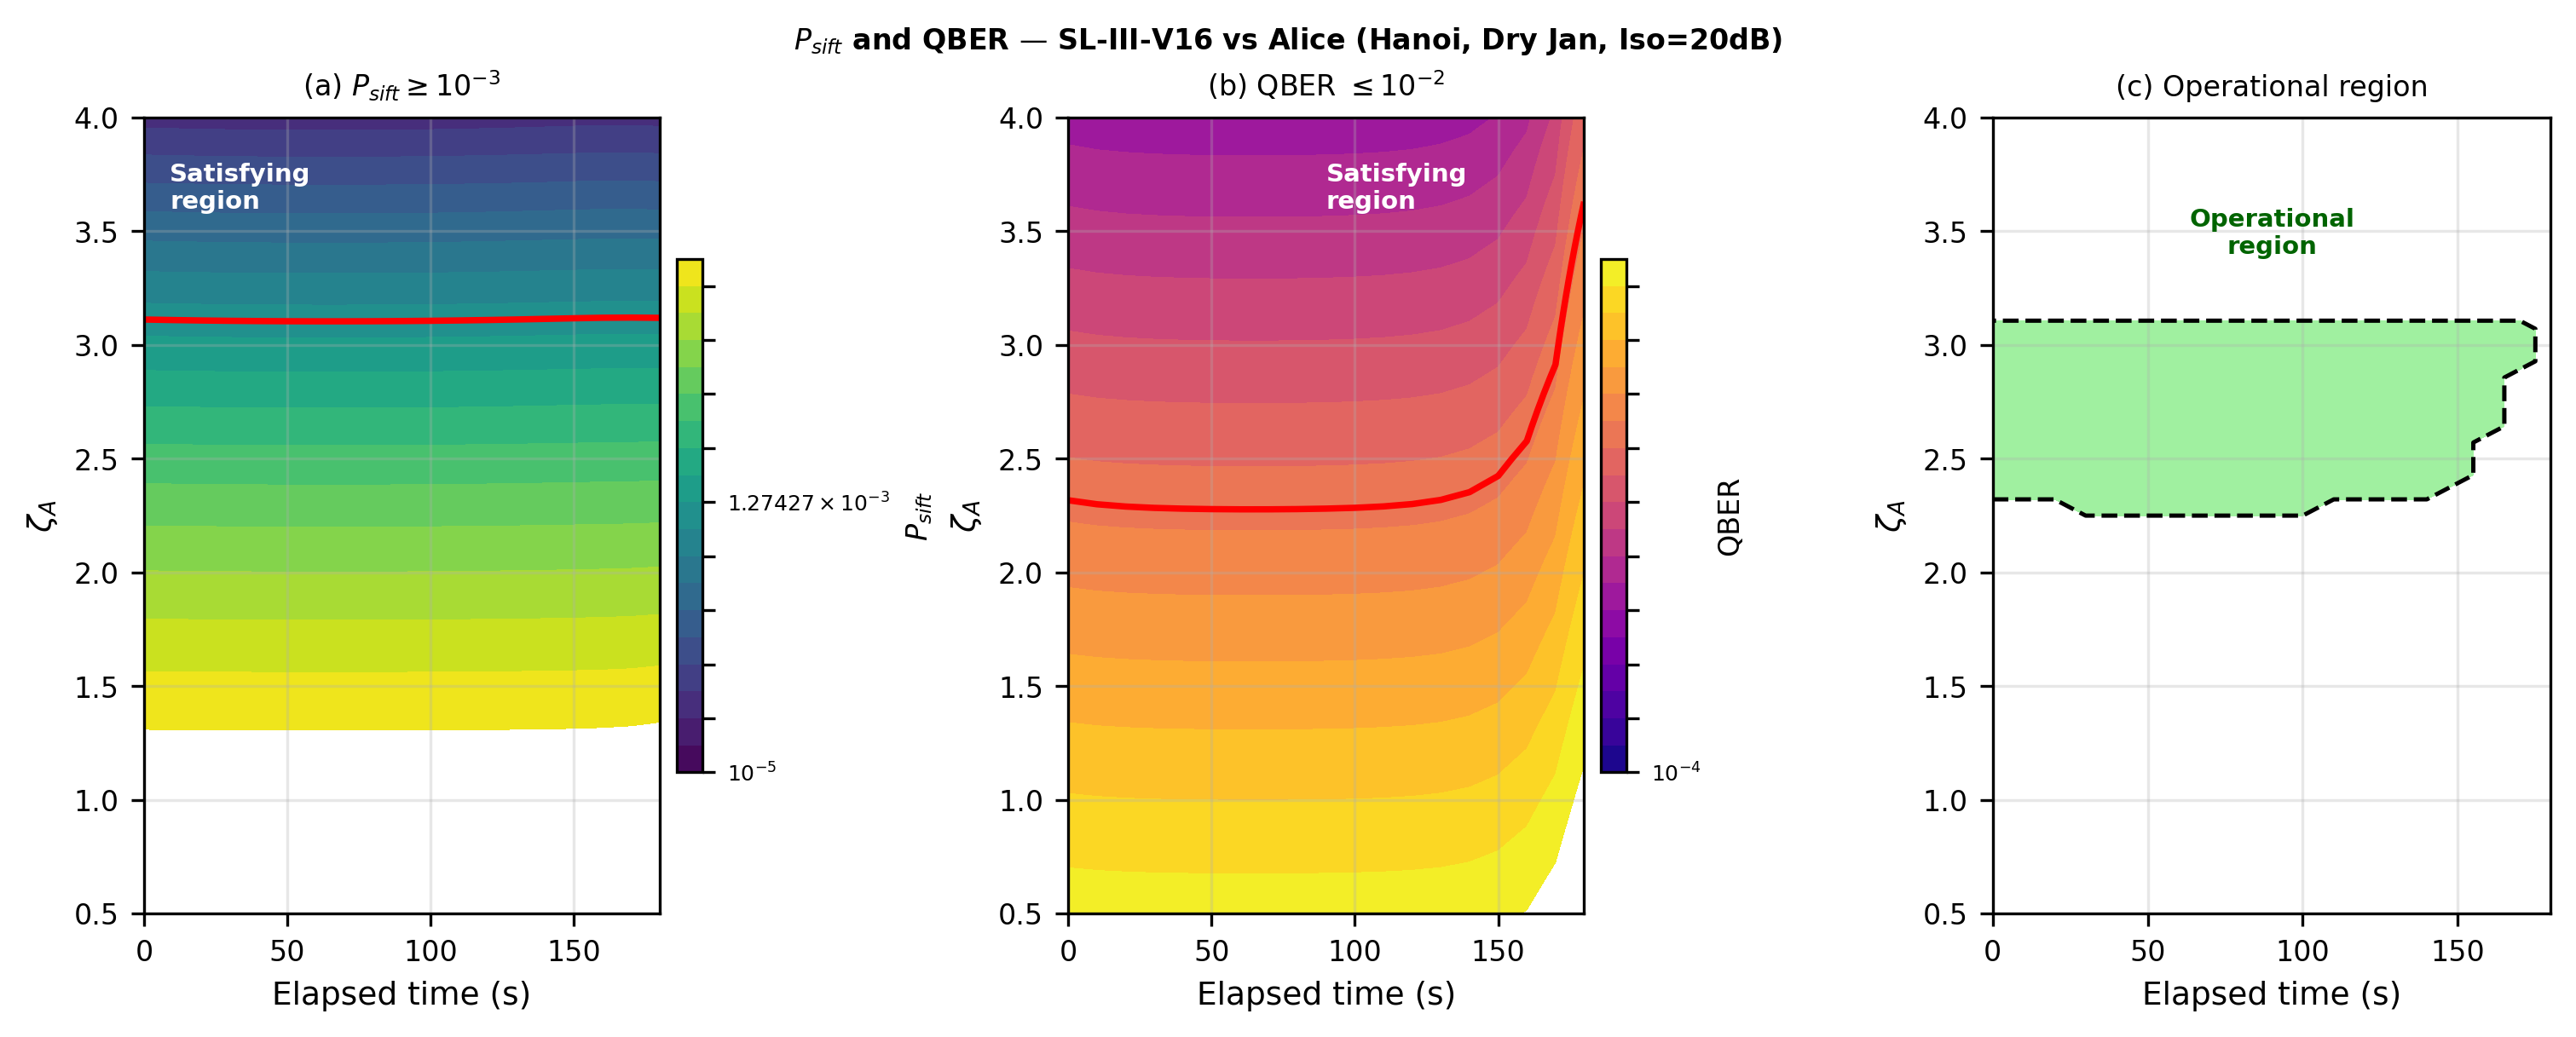

In [6]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(10, 4.0))

# Relative elapsed time within pass (0 = pass start)
t_rel = pass_elapsed - pass_elapsed[0]

# (a) Psift contourf — log scale
ax = axes[0]
Psift_safe = np.where(Psift_grid > 0, Psift_grid, 1e-10)
levels_p = np.logspace(-5, -1, 20)
cf1 = ax.contourf(t_rel, zeta_c_range, Psift_safe,
                   levels=levels_p, norm=mcolors.LogNorm(), cmap='viridis')
ax.contour(t_rel, zeta_c_range, Psift_safe,
           levels=[1e-3], colors='red', linewidths=1.8)
ax.text(t_rel[-1]*0.05, zeta_c_range[-1]*0.9, 'Satisfying\nregion',
        fontsize=7, color='white', fontweight='bold')
cbar1 = plt.colorbar(cf1, ax=ax, fraction=0.046, pad=0.03)
cbar1.set_label('$P_{sift}$', fontsize=8)
cbar1.ax.tick_params(labelsize=6)
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel("$\\zeta_A$")
ax.set_title(f'(a) $P_{{sift}} \\geq 10^{{-3}}$', fontsize=8)

# (b) QBER contourf — log scale
ax = axes[1]
QBER_safe = np.where(QBER_grid > 0, QBER_grid, 1e-10)
levels_q = np.logspace(-4, -1, 20)
cf2 = ax.contourf(t_rel, zeta_c_range, QBER_safe,
                   levels=levels_q, norm=mcolors.LogNorm(), cmap='plasma')
ax.contour(t_rel, zeta_c_range, QBER_safe,
           levels=[1e-2], colors='red', linewidths=1.8)
ax.text(t_rel[-1]*0.5, zeta_c_range[-1]*0.9, 'Satisfying\nregion',
        fontsize=7, color='white', fontweight='bold')
cbar2 = plt.colorbar(cf2, ax=ax, fraction=0.046, pad=0.03)
cbar2.set_label('QBER', fontsize=8)
cbar2.ax.tick_params(labelsize=6)
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel("$\\zeta_A$")
ax.set_title(f'(b) QBER $\\leq 10^{{-2}}$', fontsize=8)

# (c) Operational region
ax = axes[2]
operational = (Psift_grid >= 1e-3) & (QBER_grid <= 1e-2)
ax.contourf(t_rel, zeta_c_range, operational.astype(float),
            levels=[0, 0.5, 1.0],
            colors=['white', 'lightgreen'], alpha=0.85)
ax.contour(t_rel, zeta_c_range, operational.astype(float),
           levels=[0.5], colors='black', linewidths=1.2, linestyles='--')
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel("$\\zeta_A$")
ax.set_title(f'(c) Operational region', fontsize=8)
ax.text(t_rel[-1]*0.5, zeta_c_range[-1]*0.85, 'Operational\nregion',
        ha='center', fontsize=7, color='darkgreen', fontweight='bold')

op_zeta = [zc for z_idx, zc in enumerate(zeta_c_range) if np.any(operational[z_idx, :])]
if op_zeta:
    print(f'Operational zeta_A range: {min(op_zeta):.3f} < zeta_A < {max(op_zeta):.3f}')
    print(f'Max communication time in operational region: '
          f'{np.sum(operational.any(axis=0)) * 10:.0f}s')

plt.suptitle(f'$P_{{sift}}$ and QBER — {best["name"]} vs Alice (Hanoi, Dry Jan, Iso=20dB)',
             fontsize=8, fontweight='bold')
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig17_psift_qber_contourf_hanoi.png', bbox_inches='tight', dpi=300)
plt.show()

In [7]:
## Fig 10 Style: Coverage Area + Communication Time Duration

# Time of max elevation
idx_max_elev = np.argmax(best['elevs_fine'])
t_max_elev   = t_fine[idx_max_elev]
print(f'Max elevation: {best["elevs_fine"][idx_max_elev]:.1f}° at t={elapsed_s[idx_max_elev]:.0f}s')

# Grid: Vietnam + ASEAN region (Paper 1 uses 100×100 grid)
lat_grid = np.linspace(5, 25, 80)
lon_grid = np.linspace(98, 120, 80)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

print('Computing elevation grid at max elevation time...')
elev_grid = np.zeros_like(LON)
for i in range(len(lat_grid)):
    for j in range(len(lon_grid)):
        obs = wgs84.latlon(lat_grid[i], lon_grid[j])
        diff = best_sat - obs
        topo = diff.at(t_max_elev)
        alt, _, _ = topo.altaz()
        elev_grid[i, j] = alt.degrees

# Communication time: total seconds both Alice (Hanoi) and Bob (grid point) see satellite
# Use the full pass window (t_fine array)
print('Computing communication time grid...')
comm_time_grid = np.zeros_like(LON)
for i in range(len(lat_grid)):
    for j in range(len(lon_grid)):
        obs_bob = wgs84.latlon(lat_grid[i], lon_grid[j])
        diff_bob = best_sat - obs_bob
        topo_bob = diff_bob.at(t_fine)
        alt_bob, _, _ = topo_bob.altaz()
        elev_bob = np.array(alt_bob.degrees)
        # Alice elevation (already computed)
        elev_alice = best['elevs_fine']
        # Both must see satellite above MIN_ELEV
        both_visible = (elev_alice >= MIN_ELEV) & (elev_bob >= MIN_ELEV)
        comm_time_grid[i, j] = np.sum(both_visible) * 10.0  # seconds

print(f'Max comm time: {comm_time_grid.max():.0f}s = {comm_time_grid.max()/60:.1f} min')
print(f'Coverage fraction (elev>{MIN_ELEV}°): {np.mean(elev_grid >= MIN_ELEV)*100:.1f}%')
print(f'Area with comm time > 180s: {np.mean(comm_time_grid > 180)*100:.1f}%')

Max elevation: 86.0° at t=60s
Computing elevation grid at max elevation time...
Computing communication time grid...


Max comm time: 190s = 3.2 min
Coverage fraction (elev>30.0°): 33.1%
Area with comm time > 180s: 5.2%


## 5. Plot Fig 10 Style: Coverage Area + Communication Time Map

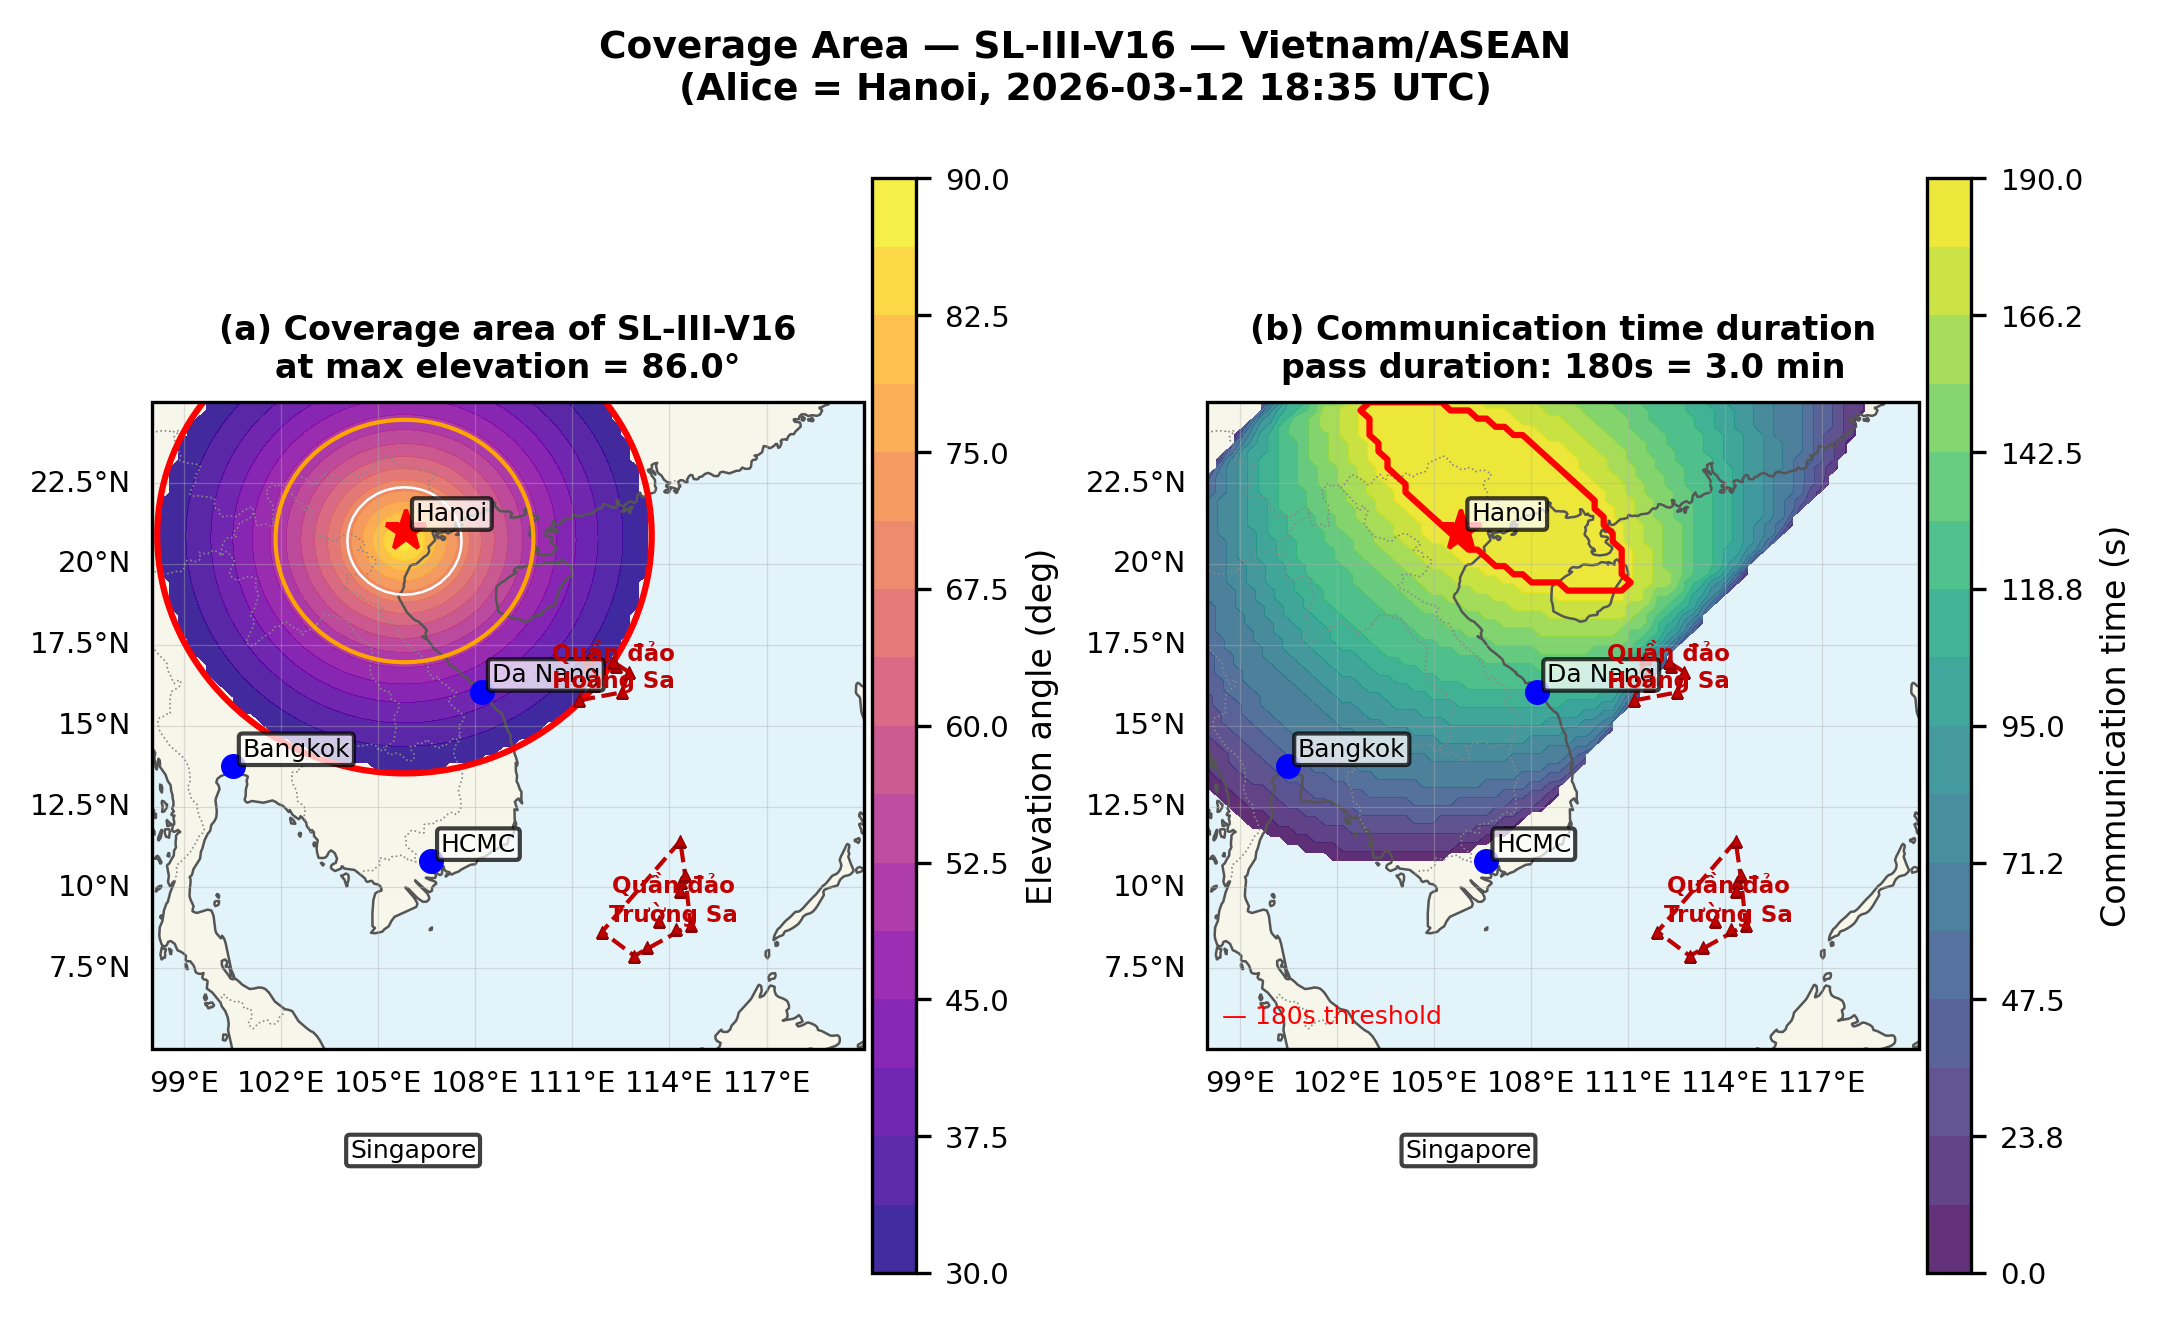

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(7.16, 4.5),
                          subplot_kw={'projection': ccrs.PlateCarree()})

vn_cities = {
    'Hanoi':     (gs_hanoi['lat'],                     gs_hanoi['lon']),
    'Da Nang':   (GROUND_STATIONS['danang']['lat'],    GROUND_STATIONS['danang']['lon']),
    'HCMC':      (GROUND_STATIONS['hcmc']['lat'],      GROUND_STATIONS['hcmc']['lon']),
    'Bangkok':   (GROUND_STATIONS['bangkok']['lat'],   GROUND_STATIONS['bangkok']['lon']),
    'Singapore': (GROUND_STATIONS['singapore']['lat'], GROUND_STATIONS['singapore']['lon']),
}

for ax in axes:
    ax.set_extent([98, 120, 5, 25], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor='#f5f5e8', alpha=0.9)
    ax.add_feature(cfeature.OCEAN,     facecolor='#d8eef8', alpha=0.7)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='#555')
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':', edgecolor='#888')
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4,
                      x_inline=False, y_inline=False)
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 7}; gl.ylabel_style = {'size': 7}
    # Mark cities
    for city, (lat, lon) in vn_cities.items():
        marker = 'r*' if city == 'Hanoi' else 'bo'
        ms = 10 if city == 'Hanoi' else 5
        ax.plot(lon, lat, marker, markersize=ms, transform=ccrs.PlateCarree(), zorder=6)
        ax.text(lon + 0.3, lat + 0.3, city, fontsize=6,
                transform=ccrs.PlateCarree(), zorder=7,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.75))
    # Draw Hoang Sa / Truong Sa
    draw_vietnam_islands(ax, use_cartopy=True)

# (a) Coverage area at max elevation time
ax = axes[0]
elev_masked = np.where(elev_grid >= MIN_ELEV, elev_grid, np.nan)
cf1 = ax.contourf(LON, LAT, elev_masked,
                   levels=np.linspace(MIN_ELEV, 90, 17),
                   cmap='plasma', transform=ccrs.PlateCarree(), alpha=0.85)
ax.contour(LON, LAT, elev_grid,
           levels=[MIN_ELEV, 50, 70],
           colors=['red', 'orange', 'white'],
           linewidths=[1.5, 1.0, 0.6],
           transform=ccrs.PlateCarree())
cbar1 = plt.colorbar(cf1, ax=ax, shrink=0.9, pad=0.01, aspect=25)
cbar1.set_label('Elevation angle (deg)', fontsize=8)
cbar1.ax.tick_params(labelsize=7)
ax.set_title(f'(a) Coverage area of {best["name"]}\n'
             f'at max elevation = {best["elevs_fine"][idx_max_elev]:.1f}°',
             fontsize=8, fontweight='bold')

# (b) Communication time duration
ax = axes[1]
comm_masked = np.where(comm_time_grid > 0, comm_time_grid, np.nan)
max_ct = comm_time_grid.max()
cf2 = ax.contourf(LON, LAT, comm_masked,
                   levels=np.linspace(0, max_ct, 17),
                   cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.85)
if max_ct > 180:
    ax.contour(LON, LAT, comm_time_grid,
               levels=[180], colors='red', linewidths=1.5,
               transform=ccrs.PlateCarree())
    ax.text(0.02, 0.04, '— 180s threshold', transform=ax.transAxes,
            fontsize=6, color='red')
cbar2 = plt.colorbar(cf2, ax=ax, shrink=0.9, pad=0.01, aspect=25)
cbar2.set_label('Communication time (s)', fontsize=8)
cbar2.ax.tick_params(labelsize=7)
ax.set_title(f'(b) Communication time duration\n'
             f'pass duration: {pass_dur_s:.0f}s = {pass_dur_s/60:.1f} min',
             fontsize=8, fontweight='bold')

plt.suptitle(f'Coverage Area — {best["name"]} — Vietnam/ASEAN\n'
             f'(Alice = Hanoi, {T_WIN_START.strftime("%Y-%m-%d %H:%M UTC")})',
             fontsize=9, fontweight='bold')
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig18_coverage_area_vietnam.png', bbox_inches='tight', dpi=300)
plt.show()

## 6. Multi-city: SKR vs Elapsed Time — Hà Nội, Đà Nẵng, TP.HCM

Với mỗi thành phố: tìm vệ tinh tốt nhất trong window, tính SKR vs elapsed time (dry season).

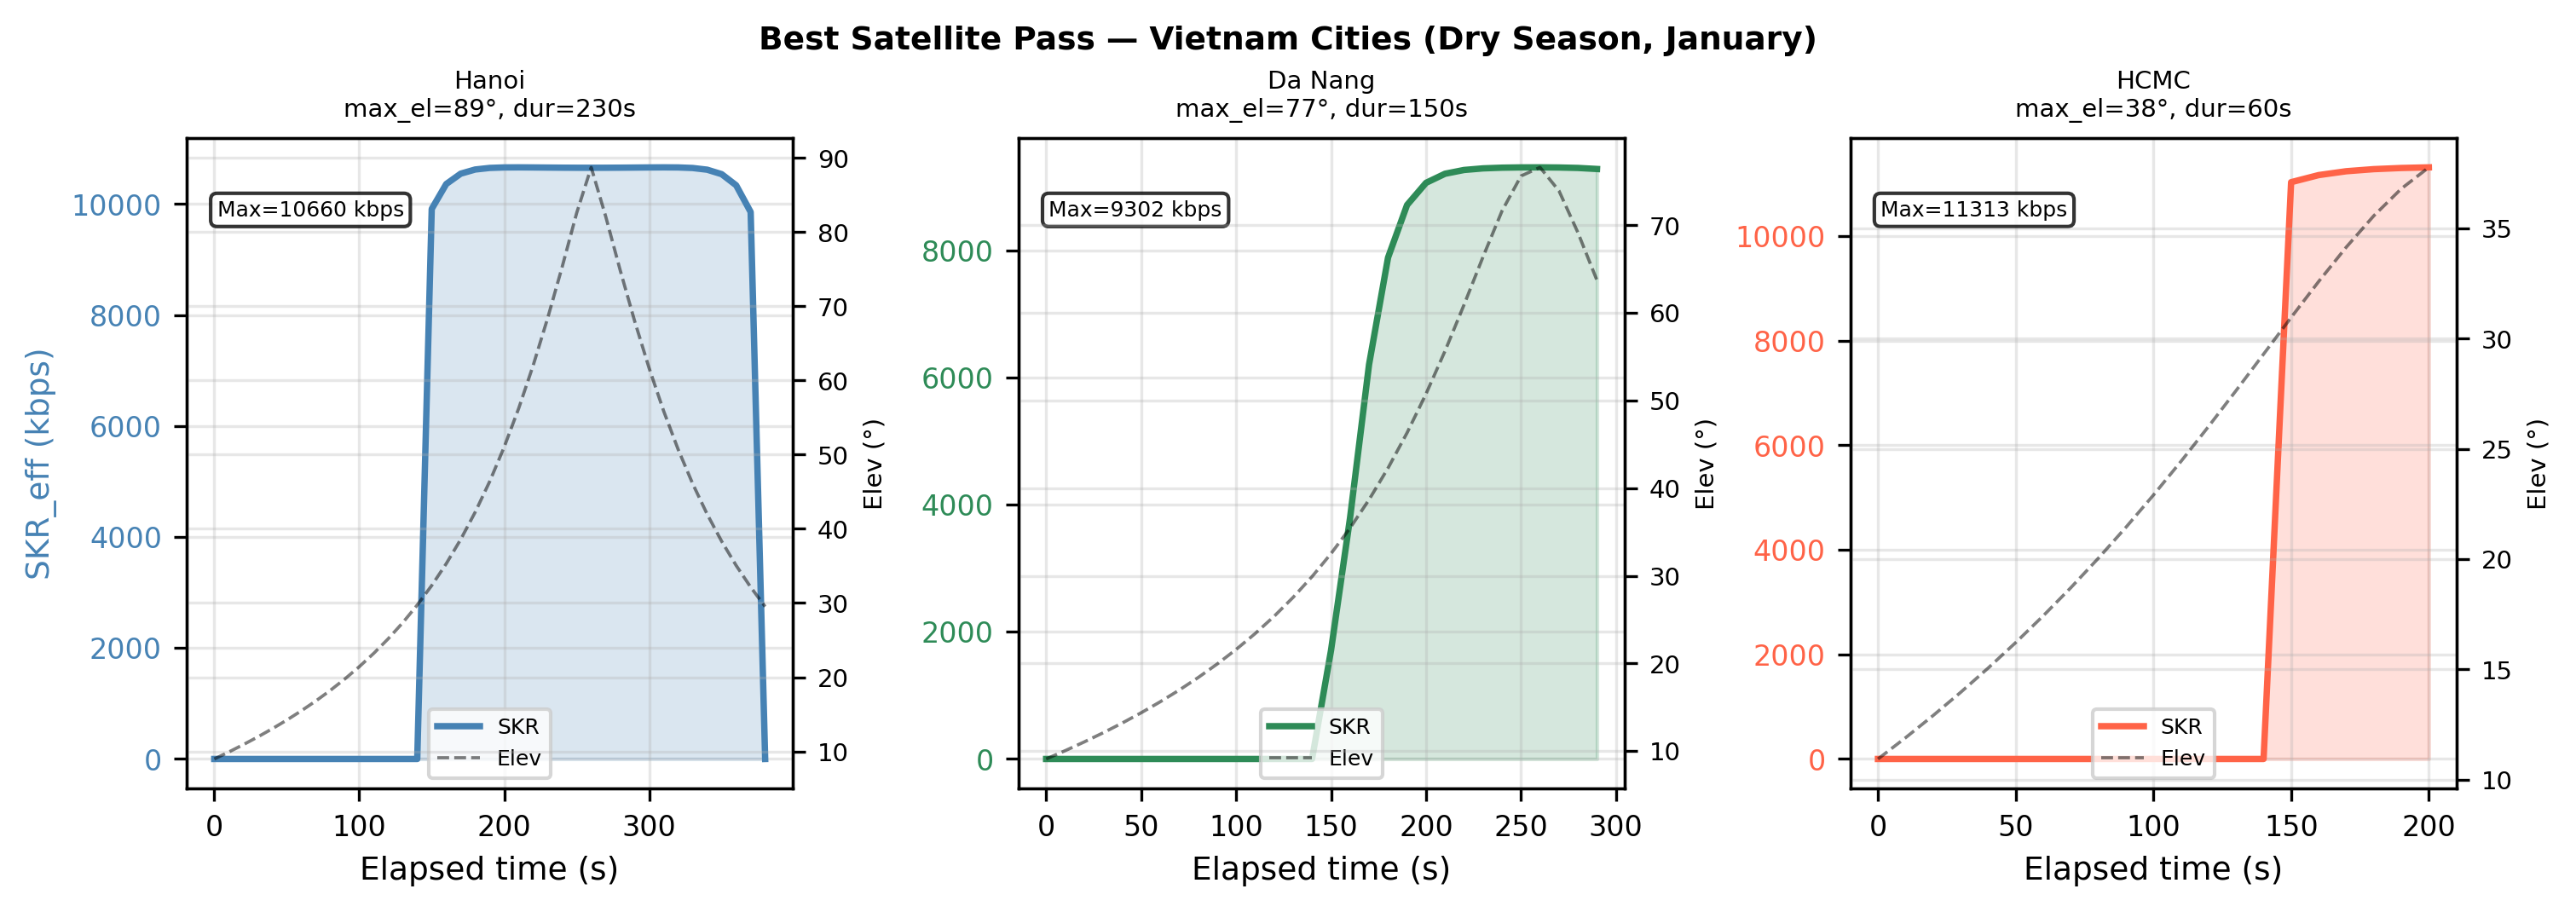

In [9]:
vn_cities_list = [
    ('hanoi',  'Hanoi',   'steelblue', 1),
    ('danang', 'Da Nang', 'seagreen',  1),
    ('hcmc',   'HCMC',    'tomato',    1),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), sharey=False)

for ax, (city_key, city_label, color, month) in zip(axes, vn_cities_list):
    gs_c  = GROUND_STATIONS[city_key]
    wx_c  = get_city_params(city_key, month)
    obs_c = wgs84.latlon(gs_c['lat'], gs_c['lon'], elevation_m=gs_c['alt_m'])

    # Find best satellite for this city in the same window
    city_vis = []
    for sat in satellites:
        diff = sat - obs_c
        topo = diff.at(t_fine)
        alt, _, _ = topo.altaz()
        elevs = np.array(alt.degrees)
        max_el = elevs.max()
        if max_el >= MIN_ELEV:
            city_vis.append({'sat': sat, 'name': sat.name,
                             'elevs_fine': elevs, 'max_el': max_el})

    if not city_vis:
        ax.text(0.5, 0.5, 'No passes', ha='center', va='center',
                transform=ax.transAxes, fontsize=9)
        ax.set_title(city_label)
        continue

    city_vis.sort(key=lambda x: x['max_el'], reverse=True)
    best_c = city_vis[0]

    pass_mask_c = best_c['elevs_fine'] >= MIN_ELEV
    pass_idx_c  = np.where(pass_mask_c)[0]
    if len(pass_idx_c) == 0:
        continue
    # Expand window ±15 steps (150s) for context
    _p = 15
    _ws = max(0, pass_idx_c[0] - _p)
    _we = min(len(elapsed_s)-1, pass_idx_c[-1] + _p)
    pe_c = elapsed_s[_ws:_we+1]
    el_c = best_c['elevs_fine'][_ws:_we+1]
    t_rel_c = pe_c - pe_c[0]

    skr_c = []
    for elev in el_c:
        if elev < MIN_ELEV:
            skr_c.append(0.0)
            continue
        zeta = 90.0 - elev
        ch = compute_channel(H_S_KM, zeta)
        hl = compute_hl(zeta_deg=zeta, V_km=wx_c['V_km'], R_mm_h=wx_c['R_mm_h'])
        p  = compute_sikd_performance(ch['hg'], hl, ch['sigma_X2'], **PARAMS)
        skr_c.append(p['SKR_kbps'] * (1.0 - wx_c['P_cloud']))
    skr_c = np.array(skr_c)

    ax2 = ax.twinx()
    ax.fill_between(t_rel_c, skr_c, alpha=0.2, color=color)
    ax.plot(t_rel_c, skr_c, color=color, linewidth=1.8, label='SKR')
    ax2.plot(t_rel_c, el_c, 'k--', linewidth=0.9, alpha=0.5, label='Elev')
    ax.set_xlabel('Elapsed time (s)')
    if ax == axes[0]:
        ax.set_ylabel('SKR_eff (kbps)', color=color)
    ax2.set_ylabel('Elev (°)', fontsize=7)
    ax.tick_params(axis='y', labelcolor=color)
    ax2.tick_params(axis='y', labelsize=7)
    ax.set_title(f'{city_label}\nmax_el={best_c["max_el"]:.0f}°, dur={len(pass_idx_c)*10:.0f}s',
                 fontsize=7)
    if skr_c.max() > 0:
        ax.text(0.05, 0.88, f'Max={skr_c.max():.0f} kbps',
                transform=ax.transAxes, fontsize=6,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, loc='lower center', fontsize=6)

plt.suptitle('Best Satellite Pass — Vietnam Cities (Dry Season, January)',
             fontsize=9, fontweight='bold')
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig19_multicity_best_pass.png', bbox_inches='tight', dpi=300)
plt.show()